In [1]:
import itertools
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import IN, LIF, PSP

from sango.backend import SimBrian

In [2]:
# Input network with spike times
class SpikeGenerator(Network):
    def __init__(self, spike_times):
        super().__init__()
        self.spike_times = spike_times # n x t (eventlist)

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        self.output = NodeList(self.spikegen[:])
        
        return

In [3]:
# Detector over multiple coincidence patterns
class CoincidenceDetector(Network):
    def __init__(self, num_patterns=8, len_patterns=2, max_delay=5):
        super().__init__()
        self.num_patterns = num_patterns
        self.len_patterns = len_patterns
        self.max_delay = max_delay

        self.input = NodePort()

    def build(self):
        # Instantiate detector neurons
        self.detector = NodeGroup(
            LIF(threshold=(self.len_patterns-0.1)), self.num_patterns)

        # Populate edges and delays
        assert self.len_patterns <= self.input.size, (
            f"Pattern length {self.len_patterns} ",
            f"greater than inputs {self.input.size}")
        edges = []
        delays = []
        for detector_index in range(self.num_patterns):
            permuted_input = np.random.permutation(self.input.size)
            for index, pattern in enumerate(range(self.len_patterns)):
                edges.append((permuted_input[index], detector_index))
                delays.append(float(np.random.randint(self.max_delay) + 1))
        
        # Instantiate projection patterns
        self.projection = EdgeGroup(
            self.input, self.detector, PSP(), edges=edges, delay=delays)

        # Output references the detector neurons
        self.output = NodeList(self.detector[:])

info: adding network sg
info: adding network cd
info: building network sg
info: linking port cd.input
info: resolving dependency for cd.input
info: building network cd
info: flattening network topology


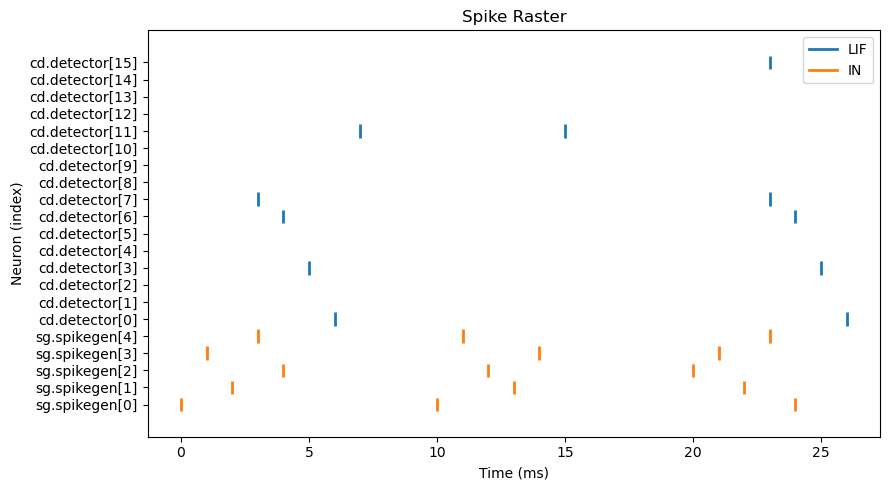

In [4]:
# Testing the coincidence detector on its own
input_times = [[0, 10, 24],
               [2, 13, 22],
               [4, 12, 20],
               [1, 14, 21],
               [3, 11, 23]]

net = Network()

net.sg = SpikeGenerator(input_times)
net.cd = CoincidenceDetector(num_patterns=16)
net.bind(net.sg.output, net.cd.input)

net.build()

sim = SimBrian(net)
sim.compile()
sim.run(40.0)

# Visualize the spike raster
sim.plot_spikes(figsize=(9, 5), linewidths=2.0, tick_names=True)

In [5]:
# A collection of coincidence detectors
class PatternBank(Network):
    def __init__(self, num_detectors=16, patterns_per_detector=8, len_patterns=2):
        super().__init__()
        self.num_detectors = num_detectors
        self.patterns_per_detector = patterns_per_detector
        self.len_patterns = len_patterns

        self.input = NodePort()

    def build(self):
        # List of coincidence detectors
        self.cd = [CoincidenceDetector(num_patterns=self.patterns_per_detector,
                                       len_patterns=self.len_patterns)
                   for _ in range(self.num_detectors)]

        # Input relay for readability
        self.input_relay = NodeGroup(LIF(threshold=0.9), self.input.size)
        self.input_conn = EdgeGroup(self.input, self.input_relay, PSP(),
                                    edges=[(i,i) for i in range(self.input.size)])
        
        # Forward the input
        for i in range(self.num_detectors):
            self.bind(self.input_relay, self.cd[i].input)

        # Perform disjunction on the outputs (OR)
        self.output = NodeGroup(LIF(threshold=0.9), self.num_detectors)

        # Reduce and concatenate the outputs
        self.reduction = []
        for j in range(self.num_detectors):
            self.reduction.append(EdgeGroup(
                self.cd[j].output, self.output, PSP(),
                edges=[(i,j) for i in range(self.patterns_per_detector)]))

In [6]:
# A collection of pattern banks, with readout vector
class PatternDetector(Network):
    def __init__(self, num_banks=4, input_subset_size=8,
                 detectors_per_bank=16, patterns_per_detector=8,
                 len_patterns=2, readout_threshold=2):
        super().__init__()
        self.num_banks = num_banks
        self.input_subset_size = input_subset_size
        self.detectors_per_bank = detectors_per_bank
        self.patterns_per_detector = patterns_per_detector
        self.len_patterns = len_patterns
        self.readout_threshold = readout_threshold

        self.input = NodePort()

    def build(self):
        # List of pattern banks
        self.bank = [PatternBank(num_detectors=self.detectors_per_bank,
                                 patterns_per_detector=self.patterns_per_detector,
                                 len_patterns=self.len_patterns)
                     for _ in range(self.num_banks)]
        
        # Readout vector performs threshold on pattern banks (weak conjunction?)
        self.readout = NodeGroup(
            LIF(threshold=self.readout_threshold-0.1), self.detectors_per_bank)

        # Forward input and accumulate outputs
        self.input_subset = []
        self.accumulator = []
        for bank_index in range(self.num_banks):
            # Each pattern bank sees subset of input
            permuted_input = np.random.permutation(self.input.size)
            self.input_subset.append(
                NodeList([self.input[permuted_input[index]]
                          for index in range(self.input_subset_size)]))
            self.bind(self.input_subset[bank_index], self.bank[bank_index].input)
            
            # Accumulate the outputs for thresholding
            self.accumulator.append(EdgeGroup(
                self.bank[bank_index].output, self.readout, PSP(),
                edges=[(i,i) for i in range(self.detectors_per_bank)]))

        # Output references the readout neurons
        self.output = NodeList(self.readout[:])

In [7]:
# Inputs
num_inputs = 32
dur_inputs = 100
input_prob = 0.1

# Dense vector (just random 0s and 1s)
input_spikes = np.random.binomial(1, input_prob, (num_inputs, dur_inputs))

# Sparse vector (only spike times)
in_n , in_t = np.where(input_spikes == 1)
input_times = [[] for _ in range(num_inputs)]
for n, t in zip(in_n, in_t):
    input_times[n].append(t)

# Pattern Detector
num_outputs = 24
num_banks = 8
readout_threshold = 3

net = Network()

net.sg = SpikeGenerator(input_times)
net.pd = PatternDetector(num_banks=num_banks, detectors_per_bank=num_outputs,
                         readout_threshold=readout_threshold)
net.bind(net.sg.output, net.pd.input)

net.build()

info: adding network sg
info: adding network pd
info: building network sg
info: linking port pd.input
info: resolving dependency for pd.input
info: building network pd
info: adding list of networks pd.bank
info: adding empty list pd.input_subset
info: adding empty list pd.accumulator
info: linking port pd.bank[0].input
info: linking port pd.bank[1].input
info: linking port pd.bank[2].input
info: linking port pd.bank[3].input
info: linking port pd.bank[4].input
info: linking port pd.bank[5].input
info: linking port pd.bank[6].input
info: linking port pd.bank[7].input
info: resolving dependency for pd.bank[0].input
info: resolving dependency for pd.bank[1].input
info: resolving dependency for pd.bank[2].input
info: resolving dependency for pd.bank[3].input
info: resolving dependency for pd.bank[4].input
info: resolving dependency for pd.bank[5].input
info: resolving dependency for pd.bank[6].input
info: resolving dependency for pd.bank[7].input
info: building network pd.bank[0]
info: add

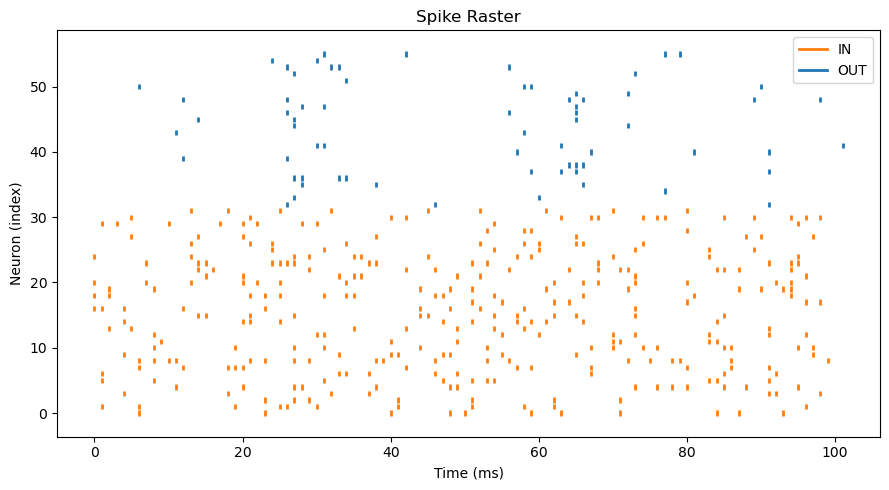

In [8]:
# Simulation in Brian
sim = SimBrian(net)
sim.compile()
sim.run(120.0)

# Get reduced spike list (just I/O)
spike_list = sim.get_spikes()
io_spike_list = []
for i in range(num_inputs):
    io_spike_list.append(spike_list[sim.node_map[net.sg.output[i].name]])
for i in range(num_outputs):
    io_spike_list.append(spike_list[sim.node_map[net.pd.output[i].name]])

# Visualize the spike raster
plt.figure(figsize=(9, 5))

# Colored lines (for legend)
color_dict = {'IN': 'C1', 'OUT': 'C0'}
for key in color_dict.keys():
    plt.plot(0,0,'-',color=color_dict[key],linewidth=2.0)

# Color the rows according to population
event_color = []
event_color.extend(['C1'] * num_inputs)
event_color.extend(['C0'] * num_outputs)

# The spike raster is plotted using eventplot
plt.eventplot(io_spike_list, colors=event_color, lineoffsets=1,
              linelengths=0.8, linewidths=2.0)

plt.title('Spike Raster')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron (index)')
plt.tight_layout()
plt.legend(color_dict.keys())

In [9]:
# Smaller network for plotting structure

# Inputs
num_inputs = 8
input_times = [[0] for _ in range(num_inputs)]

# Pattern Detector
num_outputs = 4
num_banks = 3
input_subset = 6
patterns_per_detector = 4

net = Network()

net.sg = SpikeGenerator(input_times)
net.pd = PatternDetector(num_banks=num_banks, input_subset_size=input_subset,
                         detectors_per_bank=num_outputs,
                         patterns_per_detector=patterns_per_detector)
net.bind(net.sg.output, net.pd.input)

net.build()

info: adding network sg
info: adding network pd
info: building network sg
info: linking port pd.input
info: resolving dependency for pd.input
info: building network pd
info: adding list of networks pd.bank
info: adding empty list pd.input_subset
info: adding empty list pd.accumulator
info: linking port pd.bank[0].input
info: linking port pd.bank[1].input
info: linking port pd.bank[2].input
info: resolving dependency for pd.bank[0].input
info: resolving dependency for pd.bank[1].input
info: resolving dependency for pd.bank[2].input
info: building network pd.bank[0]
info: adding list of networks pd.bank[0].cd
info: adding empty list pd.bank[0].reduction
info: linking port pd.bank[0].cd[0].input
info: linking port pd.bank[0].cd[1].input
info: linking port pd.bank[0].cd[2].input
info: linking port pd.bank[0].cd[3].input
info: resolving dependency for pd.bank[0].cd[0].input
info: resolving dependency for pd.bank[0].cd[1].input
info: resolving dependency for pd.bank[0].cd[2].input
info: reso

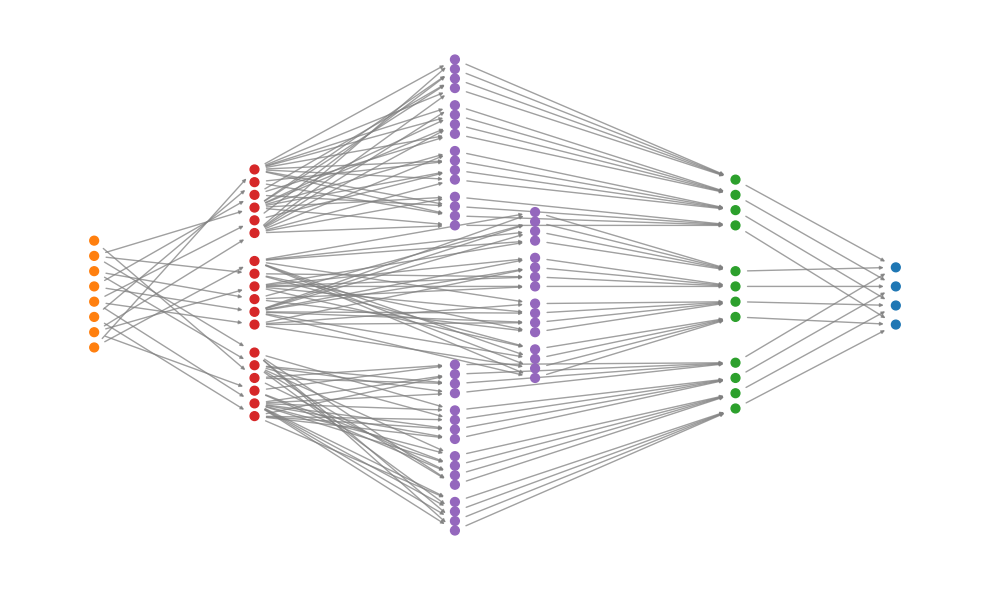

In [10]:
# Get networkx graph and indexes 
graph = net.graph()
pos = nx.circular_layout(graph)
index_map = {node: i for i, node in enumerate(graph.nodes())}
color_map = ['black' for node in graph] # default

# Inputs / spike generator
for i in range(num_inputs):
    pos[net.sg.spikegen[i].name][0] = 0
    pos[net.sg.spikegen[i].name][1] = 0.8 * (i / num_inputs) - 0.4
    color_map[index_map[net.sg.spikegen[i].name]] = 'tab:orange'

# Outputs / readout vector
for i in range(num_outputs):
    pos[net.pd.output[i].name][0] = 1
    pos[net.pd.output[i].name][1] = 0.5 * (i / num_outputs) - 0.25
    color_map[index_map[net.pd.output[i].name]] = 'tab:blue'

# Pattern bank inputs
for b in range(num_banks):
    for i in range(input_subset):
        pos[net.pd.bank[b].input_relay[i].name][0] = 0.2
        pos[net.pd.bank[b].input_relay[i].name][1] = (
            (b * 0.6) + 0.5 * (i / input_subset - 0.5) - 0.6)
        color_map[index_map[net.pd.bank[b].input_relay[i].name]] = 'tab:red'

# Coincidence detectors
for b in range(num_banks):
    for c in range(num_outputs):
        for i in range(patterns_per_detector):
            pos[net.pd.bank[b].cd[c].detector[i].name][0] = 0.45 + (0.1 * (b % 2))
            pos[net.pd.bank[b].cd[c].detector[i].name][1] = (
                (b * 1.0) + (c * 0.3) + 0.25 * (i / patterns_per_detector - 0.5) - 1.475)
            color_map[index_map[net.pd.bank[b].cd[c].detector[i].name]] = 'tab:purple'

# Concatenated outputs
for b in range(num_banks):
    for i in range(num_outputs):
        pos[net.pd.bank[b].output[i].name][0] = 0.8
        pos[net.pd.bank[b].output[i].name][1] = (b * 0.6) + 0.4 * (i / num_outputs - 0.5) - 0.6
        color_map[index_map[net.pd.bank[b].output[i].name]] = 'tab:green'

# Plot network structure
plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(graph, pos, node_size=40, node_color=color_map)
nx.draw_networkx_edges(graph, pos, edge_color='gray', alpha=0.75, width=1, arrowsize=5)

plt.axis('off')
plt.tight_layout()